In [1]:
# instalar dependências python
import numpy as np
import matplotlib
from PIL import Image as PILImage, ImageEnhance, ImageFilter, ImageDraw, ImageFont
import imageio.v2 as imageio
from IPython.display import Image, display
import subprocess
import os
import Thiessen 

In [2]:
# 34750000.asc ou 
# bacia_fronteiras_wgs84.asc
bacia_filename = 'bacia_fronteiras_wgs84.asc'

# pr_daily_funceme_34750000_19730101_20260731.txt ou 
# pr_daily_funceme_bacia_fronteiras_wgs84_19730101_20260731.txt
precip_filename = 'pr_daily_funceme_bacia_fronteiras_wgs84_19730101_20260731.txt'

In [3]:
precip = np.loadtxt(precip_filename)[:, 3:]  # lê a partir da coluna 4
print(precip.shape)

(51, 19570)


In [4]:
lons = np.loadtxt(precip_filename)[:, 1]  # lê longitudes
lats = np.loadtxt(precip_filename)[:, 2]  # lê latitudes

In [5]:
# Será salvo em png todas as combinações encontradas
# Esse processamento pode levar algum tempo!
resultados = Thiessen.thiessen(
    precip,
    lats,
    lons,
    bacia_filename,
    pf=-1,           # ponto fora da bacia: -1 não usa nenhum ponto fora da bacia
    sep=',',         # separador de colunas do arquivo contorno da bacia
    usenc=False,     # usar apenas quando for netcdf
    figname='thiessen.png',  # descomente essa linha para plotar as figuras
    num_proc=4       # número de processadores usados para a tarefa
)[0]

In [6]:
print(resultados)

[-999.    0.    0. ...    0.    0.    0.]


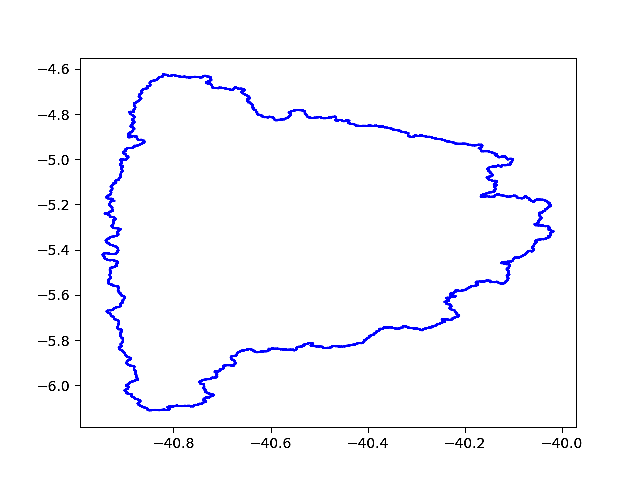

Animação criada e PNGs apagados!


In [7]:
pasta = "."
arquivos = sorted([f for f in os.listdir(pasta) if f.lower().endswith(".png")])

imagens_processadas = []

for i, arquivo in enumerate(arquivos):
    img = PILImage.open(os.path.join(pasta, arquivo)).convert("RGB")
    
    # Melhorias de estilo (opcional)
    img = ImageEnhance.Contrast(img).enhance(1.2)
    img = ImageEnhance.Color(img).enhance(1.15)
    img = img.filter(ImageFilter.SHARPEN)
    
    # Adiciona número do frame
    draw = ImageDraw.Draw(img)
    try:
        fonte = ImageFont.truetype("/System/Library/Fonts/Helvetica.ttc", 36)
    except:
        fonte = ImageFont.load_default()
    draw.text((15, 15), f"Frame {i+1}", fill=(255, 255, 255), font=fonte)
    
    imagens_processadas.append(img)

# Salva o GIF
imagens_processadas[0].save(
    "animacao.gif",
    save_all=True,
    append_images=imagens_processadas[1:],
    duration=100,   # 100 ms = 10 FPS
    loop=0
)

# Apaga os PNGs
for f in arquivos:
    os.remove(os.path.join(pasta, f))
    
# Mostra a animação embutida no Jupyter
display(Image(filename="animacao.gif"))

print("Animação criada e PNGs apagados!")